In [1]:
import os
import time
import copy
import random
import json
from pathlib import Path
from contextlib import nullcontext

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.amp import autocast, GradScaler
from torchvision import datasets, transforms

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)
from sklearn.model_selection import train_test_split

from tqdm.auto import tqdm


/home/krishna/Desktop/Adi Work/Cnn transformer hybrid/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 2912

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed()

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ============================================================
# GPU Memory Optimization
# ============================================================
if torch.cuda.is_available():
    # Reduce memory fragmentation
    os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
    torch.cuda.empty_cache()
    torch.cuda.set_per_process_memory_fraction(0.95)  # Use up to 95% of GPU memory
    
    gpu_name = torch.cuda.get_device_name(0)
    gpu_memory_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU: {gpu_name}")
    print(f"GPU Memory: {gpu_memory_gb:.2f} GB")
else:
    print("CUDA not available. Using CPU (training will be slow).")

Using device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
GPU Memory: 6.05 GB


In [4]:
# ============================================================
# Dataset Configuration
# ============================================================
# Change this path
DATASET_PATH = "../Dataset/Mendeley_Dataset"

# Choose:
# "Mendeley_Dataset" or "PlantVillage_Dataset"
DATASET_NAME = "Mendeley_Dataset"

# Validate dataset path
if not Path(DATASET_PATH).exists():
    raise FileNotFoundError(f"Dataset path not found: {DATASET_PATH}")

CONFIG = {
    "Mendeley_Dataset": {
        "num_classes": 7,
        "img_size": 224
    },
    "PlantVillage_Dataset": {
        "num_classes": 3,
        "img_size": 224
    }
}

cfg = CONFIG[DATASET_NAME]

RESULTS_DIR = Path(f"../Results/Model_2/{DATASET_NAME}")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [5]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.RandomResizedCrop(
        224,
        scale=(0.7, 0.8)
    ),

    transforms.RandomRotation(40),

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),

    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [6]:
full_dataset = datasets.ImageFolder(DATASET_PATH)

class_names = full_dataset.classes
print("Classes:", class_names)
print("Total samples:", len(full_dataset))

Classes: ['Bacteria', 'Fungi', 'Healthy', 'Nematode', 'Pest', 'Phytopthora', 'Virus']
Total samples: 3076


In [7]:
from sklearn.model_selection import train_test_split

# ============================================================
# 80:20 Stratified Split - Training and Test/Validation Sets
# ============================================================
# Prepare data for stratified split
all_targets = [full_dataset.samples[i][1] for i in range(len(full_dataset))]

# 80:20 stratified split
train_indices, test_indices = train_test_split(
    range(len(full_dataset)),
    test_size=0.2,
    stratify=all_targets,
    random_state=SEED
)

# Create subsets using indices
from torch.utils.data import Subset
train_dataset = Subset(full_dataset, train_indices)
test_dataset = Subset(full_dataset, test_indices)

# Apply transforms
train_dataset_with_transform = copy.deepcopy(train_dataset)
test_dataset_with_transform = copy.deepcopy(test_dataset)

# Create wrapper to apply different transforms
class SubsetWithTransform:
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    
    def __len__(self):
        return len(self.subset)
    
    def __getitem__(self, idx):
        img, label = self.subset[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

train_dataset = SubsetWithTransform(train_dataset_with_transform, train_transform)
test_dataset = SubsetWithTransform(test_dataset_with_transform, test_transform)

print(f"Training set size: {len(train_dataset)} (80%)")
print(f"Test/Validation set size: {len(test_dataset)} (20%)")


Training set size: 2460 (80%)
Test/Validation set size: 616 (20%)


In [8]:
# ============================================================
# DataLoader Configuration (optimized for GPU memory)
# ============================================================

BATCH_SIZE = 32 if torch.cuda.is_available() else 16

NUM_WORKERS = 4 if torch.cuda.is_available() else 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
)

# Use test_dataset for validation (as per publication specs)
val_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

# Keep test_loader as alias for evaluation
test_loader = val_loader

print(f"GPU Memory: {gpu_memory_gb:.2f}GB")
print(f"Batch Size: {BATCH_SIZE} | Workers: {NUM_WORKERS}")


GPU Memory: 6.05GB
Batch Size: 32 | Workers: 4


In [9]:
# -----------------------------
# Lightweight Cross Attention
# -----------------------------
class CrossAttention(nn.Module):
    """
    Lightweight Cross Attention between FC1 and FC2 outputs.

    Query  : FC1 output
    Key    : FC2 output
    Value  : FC2 output
    """

    def __init__(self, dim):
        super().__init__()

        self.query = nn.Linear(dim, dim)
        self.key = nn.Linear(dim, dim)
        self.value = nn.Linear(dim, dim)

        self.scale = dim ** 0.5

    def forward(self, x1, x2):
        """
        x1: FC1 output
        x2: FC2 output
        """

        Q = self.query(x1)
        K = self.key(x2)
        V = self.value(x2)

        attention_scores = torch.matmul(Q.unsqueeze(1), K.unsqueeze(2)) / self.scale
        attention_weights = F.softmax(attention_scores, dim=-1)

        attended = torch.matmul(attention_weights, V.unsqueeze(1)).squeeze(1)

        return attended

In [10]:
# -----------------------------
# Model 2: Lightweight CNN + Cross Attention
# -----------------------------
class LightweightCrossAttentionCNN(nn.Module):
    """
    Model 2: Lightweight CNN with Cross Attention

    Architecture:
    Input → Conv1 → Conv2 → Flatten
          → FC1 + FC2
          → Cross Attention Fusion
          → FC3
    """

    def __init__(self, num_classes):
        super().__init__()

        # Conv1
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)   # 224 -> 112
        )

        # Conv2
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)   # 112 -> 56
        )

        self.flatten_dim = 64 * 56 * 56

        # Parallel FC branches
        self.fc1 = nn.Sequential(
            nn.Linear(self.flatten_dim, 256),
            nn.ReLU(inplace=True)
        )

        self.fc2 = nn.Sequential(
            nn.Linear(self.flatten_dim, 256),
            nn.ReLU(inplace=True)
        )

        # Cross Attention Fusion
        self.cross_attention = CrossAttention(dim=256)

        # Final Classification
        self.fc3 = nn.Linear(256, num_classes)

    def forward(self, x):

        x = self.conv1(x)
        x = self.conv2(x)

        x = torch.flatten(x, 1)

        # Parallel feature projections
        f1 = self.fc1(x)
        f2 = self.fc2(x)

        # Cross-attention fusion
        fused = self.cross_attention(f1, f2)

        # Final prediction
        out = self.fc3(fused)

        return out

In [11]:
model = LightweightCrossAttentionCNN(cfg["num_classes"]).to(device)

params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {params:,}")

Parameters: 102,979,527


In [12]:
# ============================================================
# Training Configuration (Publication Level)
# ============================================================
# Adam optimizer with learning rate 0.0001
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

# ReduceLROnPlateau: Reduce learning rate by 0.2 when validation loss 
# doesn't improve for 3 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.2,
    patience=3,
    min_lr=1e-7
)

print(f"Optimizer: Adam with lr=0.0001")
print(f"Criterion: Categorical Cross-Entropy Loss")
print(f"Learning Rate Scheduler: ReduceLROnPlateau (factor=0.2, patience=3 epochs)")


Optimizer: Adam with lr=0.0001
Criterion: Categorical Cross-Entropy Loss
Learning Rate Scheduler: ReduceLROnPlateau (factor=0.2, patience=3 epochs)


In [13]:
# ============================================================
# Mixed Precision Training Configuration
# ============================================================
scaler = GradScaler(enabled=(device.type == 'cuda'))
use_amp = device.type == 'cuda'
print(f"Mixed Precision Training (AMP): {'Enabled (float16)' if use_amp else 'Disabled (CPU)'}")

# Experiment tracking
import datetime
experiment_info = {
    "timestamp": datetime.datetime.now().isoformat(),
    "dataset": DATASET_NAME,
    "batch_size": BATCH_SIZE,
    "device": str(device),
    "amp_enabled": use_amp,
    "seed": SEED
}
print(f"\nExperiment Config: {json.dumps(experiment_info, indent=2)}")

Mixed Precision Training (AMP): Enabled (float16)

Experiment Config: {
  "timestamp": "2026-05-31T11:40:15.953368",
  "dataset": "Mendeley_Dataset",
  "batch_size": 32,
  "device": "cuda",
  "amp_enabled": true,
  "seed": 2912
}


In [14]:
def train_model(model, epochs=100, patience=15, min_delta=0.001, gradient_accumulation_steps=1):
    """Train model with AMP, ReduceLROnPlateau, early stopping, and best model checkpointing.
    
    Args:
        model: Neural network model
        epochs: Maximum number of epochs (default: 100)
        patience: Early stopping patience (default: 15)
        min_delta: Minimum change in validation loss to qualify as improvement (default: 0.001)
        gradient_accumulation_steps: Gradient accumulation for larger effective batch size
    
    Returns:
        model: Trained model with best weights
        history: Training history dict
        total_time: Total training time in seconds
    """
    best_val_loss = float('inf')
    best_weights = copy.deepcopy(model.state_dict())
    early_stop_counter = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "learning_rate": []
    }

    start_time = time.time()

    for epoch in range(epochs):
        print(f"\n{'='*60}")
        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Learning Rate: {optimizer.param_groups[0]['lr']:.6f}")

        # Training with Mixed Precision
        model.train()
        train_loss, correct, total = 0, 0, 0
        epoch_start = time.time()
        accumulation_counter = 0

        for batch_idx, (images, labels) in enumerate(tqdm(train_loader, desc="Training")):
            images, labels = images.to(device), labels.to(device)

            # Automatic Mixed Precision: Forward pass in float16
            autocast_context = autocast(device_type=device.type) if use_amp else nullcontext()
            with autocast_context:
                outputs = model(images)
                loss = criterion(outputs, labels)
                # Scale loss for gradient accumulation
                loss = loss / gradient_accumulation_steps

            # Scale loss and backward pass
            scaler.scale(loss).backward()
            accumulation_counter += 1

            if accumulation_counter % gradient_accumulation_steps == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)

            train_loss += loss.item() * gradient_accumulation_steps
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
            # Clear cache every 50 batches to prevent fragmentation
            if (batch_idx + 1) % 50 == 0:
                torch.cuda.empty_cache()

        train_acc = correct / total
        epoch_time = time.time() - epoch_start

        # Validation (full precision for accurate metrics)
        model.eval()
        val_loss, correct, total = 0, 0, 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc="Validation"):
                images, labels = images.to(device), labels.to(device)
                autocast_context = autocast(device_type=device.type) if use_amp else nullcontext()
                with autocast_context:
                    outputs = model(images)
                    loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)

                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_acc = correct / total
        val_loss_avg = val_loss / len(val_loader)

        history["train_loss"].append(train_loss/len(train_loader))
        history["val_loss"].append(val_loss_avg)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["learning_rate"].append(optimizer.param_groups[0]['lr'])

        print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
        print(f"Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss_avg:.4f}")
        print(f"Epoch Time: {epoch_time:.2f}s")

        # ModelCheckpoint: Save best model based on minimum validation loss
        if val_loss_avg < best_val_loss - min_delta:
            best_val_loss = val_loss_avg
            best_weights = copy.deepcopy(model.state_dict())
            early_stop_counter = 0

            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_val_loss': best_val_loss,
                'val_acc': val_acc,
                'config': experiment_info
            }, RESULTS_DIR / "best_lightweight_cross_attention_model.pth")

            print(f"✓ New best model saved (Val Loss: {val_loss_avg:.4f})")
        else:
            early_stop_counter += 1
            print(f"No improvement (min_delta={min_delta}). Early stopping: {early_stop_counter}/{patience}")

        # ReduceLROnPlateau: Adaptively reduce learning rate
        scheduler.step(val_loss_avg)

        # Early Stopping: Stop if no improvement for 'patience' epochs
        if early_stop_counter >= patience:
            print(f"\n{'='*60}")
            print(f"Early stopping triggered after {epoch+1} epochs")
            break

    total_time = time.time() - start_time
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()  # Ensure all GPU operations complete

    model.load_state_dict(best_weights)

    return model, history, total_time



In [15]:
def evaluate(model, loader, set_name="Test"):
    """Evaluate model and compute comprehensive metrics.
    
    Args:
        model: Trained model
        loader: Data loader
        set_name: Name of evaluation set (Train/Val/Test)
    
    Returns:
        metrics: Dictionary of evaluation metrics
        cm: Confusion matrix
        report: Classification report
    """
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc=f"Evaluating {set_name}"):
            images = images.to(device)
            labels = labels.cpu().numpy()  # FIX: Move labels to CPU before numpy

            autocast_context = autocast(device_type=device.type) if use_amp else nullcontext()
            with autocast_context:
                outputs = model(images)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()

            y_pred.extend(preds)
            y_true.extend(labels)

    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average='macro', zero_division=0),
        "Recall": recall_score(y_true, y_pred, average='macro', zero_division=0),
        "F1": f1_score(y_true, y_pred, average='macro', zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred)
    }

    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0
    )

    return metrics, cm, report

In [16]:
# ============================================================
# Train Model with Publication Configuration
# ============================================================
# Configuration:
# - Epochs: 100
# - Batch Size: 32
# - Optimizer: Adam (lr=0.0001)
# - Loss: Categorical Cross-Entropy
# - ReduceLROnPlateau: factor=0.2, patience=3 epochs
# - Early Stopping: patience=15 epochs, min_delta=0.001
# - ModelCheckpoint: saves best model based on min validation loss
# ============================================================

model, history, training_time = train_model(
    model,
    epochs=100,
    patience=15,
    min_delta=0.001
)

print(f"\nTraining completed in {training_time:.2f} seconds ({training_time/60:.2f} minutes)")



Epoch 1/100
Learning Rate: 0.000100


Validation: 100%|██████████| 20/20 [00:07<00:00,  2.76it/s]


Train Acc: 0.2528 | Val Acc: 0.3506
Train Loss: 1.7934 | Val Loss: 1.6633
Epoch Time: 25.01s
✓ New best model saved (Val Loss: 1.6633)

Epoch 2/100
Learning Rate: 0.000100


Validation: 100%|██████████| 20/20 [00:07<00:00,  2.64it/s]


Train Acc: 0.3569 | Val Acc: 0.3766
Train Loss: 1.6200 | Val Loss: 1.5633
Epoch Time: 22.22s
✓ New best model saved (Val Loss: 1.5633)

Epoch 3/100
Learning Rate: 0.000100


...

Train Acc: 0.5102 | Val Acc: 0.5227
Train Loss: 1.2328 | Val Loss: 1.2500
Epoch Time: 19.90s
No improvement (min_delta=0.001). Early stopping: 13/15

Epoch 45/100
Learning Rate: 0.000000


Validation: 100%|██████████| 20/20 [00:05<00:00,  3.83it/s]


Train Acc: 0.5207 | Val Acc: 0.5227
Train Loss: 1.2389 | Val Loss: 1.2494
Epoch Time: 19.62s
No improvement (min_delta=0.001). Early stopping: 14/15

Epoch 46/100
Learning Rate: 0.000000


Validation: 100%|██████████| 20/20 [00:05<00:00,  3.76it/s]

Train Acc: 0.5114 | Val Acc: 0.5227
Train Loss: 1.2355 | Val Loss: 1.2492
Epoch Time: 18.98s
No improvement (min_delta=0.001). Early stopping: 15/15

Early stopping triggered after 46 epochs

Training completed in 1438.68 seconds (23.98 minutes)


In [17]:
metrics, cm, report = evaluate(model, test_loader)

print(metrics)
print(report)

Evaluating Test: 100%|██████████| 20/20 [00:05<00:00,  3.73it/s]

{'Accuracy': 0.5275974025974026, 'Precision': 0.5883643159620412, 'Recall': 0.4952067550817517, 'F1': 0.5068862472260941, 'MCC': 0.42180595815215216, 'Balanced Accuracy': 0.4952067550817517}
              precision    recall  f1-score   support

    Bacteria       0.60      0.88      0.71       114
       Fungi       0.46      0.53      0.49       150
     Healthy       0.60      0.15      0.24        40
    Nematode       0.89      0.57      0.70        14
        Pest       0.46      0.28      0.35       122
 Phytopthora       0.60      0.42      0.50        69
       Virus       0.51      0.64      0.56       107

    accuracy                           0.53       616
   macro avg       0.59      0.50      0.51       616
weighted avg       0.53      0.53      0.51       616



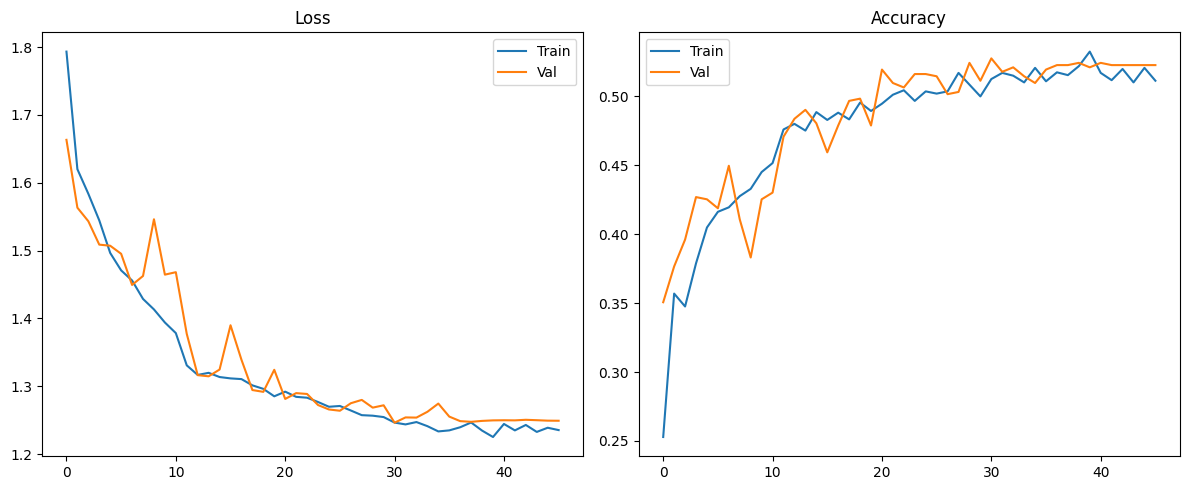

In [18]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Val")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history["train_acc"], label="Train")
plt.plot(history["val_acc"], label="Val")
plt.title("Accuracy")
plt.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_curves.png")
plt.show()

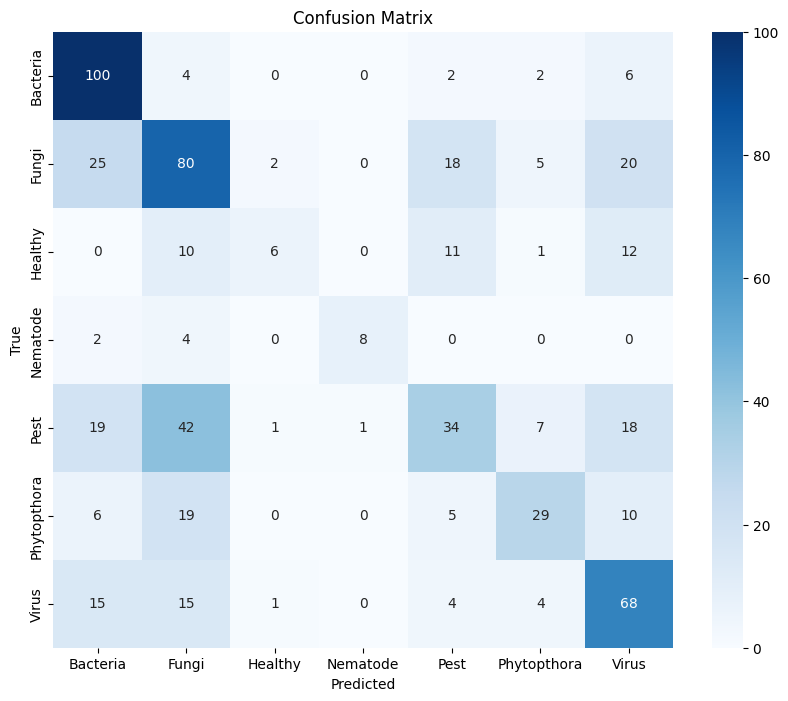

In [19]:
plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.savefig(RESULTS_DIR / "confusion_matrix.png")
plt.show()

In [20]:
# ============================================================
# Save Comprehensive Results Summary
# ============================================================
summary = {
    **metrics,
    "Training Time (sec)": training_time,
    "Parameter Count": params,
    "Best Validation Accuracy": max(history["val_acc"]),
    "Batch Size": BATCH_SIZE,
    "Mixed Precision": use_amp,
    "Device": str(device)
}

# Add experiment metadata
summary.update(experiment_info)

df = pd.DataFrame([summary])
df.to_csv(RESULTS_DIR / "results_summary.csv", index=False)

# Save training history
history_df = pd.DataFrame(history)
history_df.to_csv(RESULTS_DIR / "training_history.csv", index=False)

print("\n" + "="*60)
print("RESULTS SUMMARY")
print("="*60)
print(df.to_string())
print(f"\nResults saved to: {RESULTS_DIR}")


RESULTS SUMMARY
   Accuracy  Precision    Recall        F1       MCC  Balanced Accuracy  Training Time (sec)  Parameter Count  Best Validation Accuracy  Batch Size  Mixed Precision Device                   timestamp           dataset  batch_size device  amp_enabled  seed
0  0.527597   0.588364  0.495207  0.506886  0.421806           0.495207          1438.679566        102979527                  0.527597          32             True   cuda  2026-05-31T11:40:15.953368  Mendeley_Dataset          32   cuda         True  2912

Results saved to: ../Results/Model_2/Mendeley_Dataset
